In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:
df = pd.read_csv('fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


In [6]:
df.shape

(6000, 785)

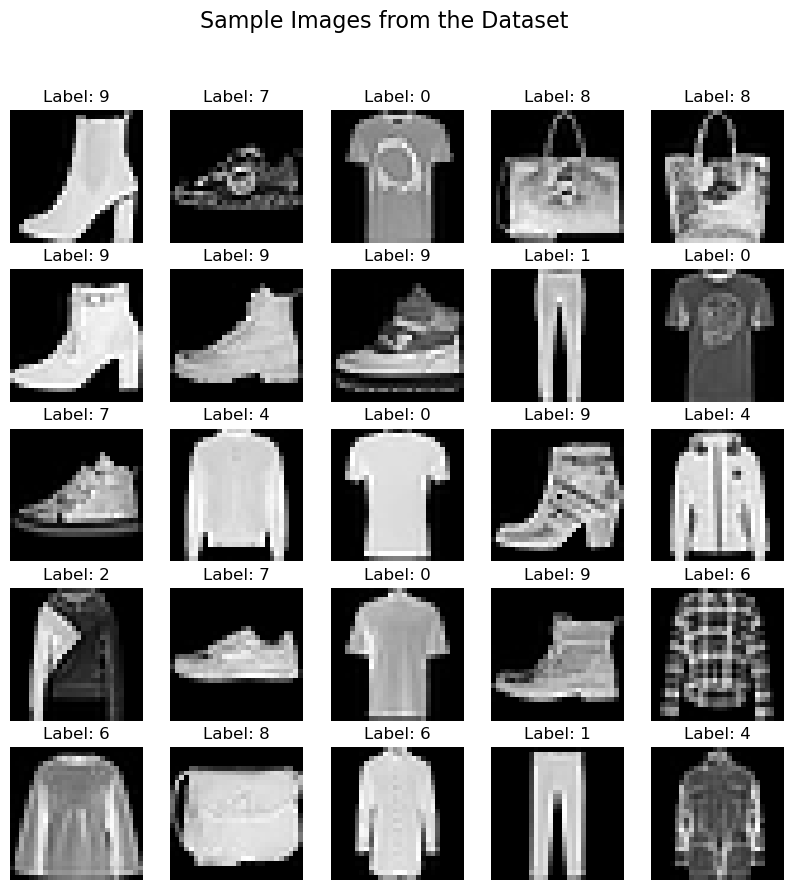

In [8]:
# Create grid of images from the dataset
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
fig.suptitle('Sample Images from the Dataset', fontsize=16)

for i,ax in enumerate(axes.flatten()):  # Why flatten? Because axes is a 2D array of shape (5, 5), and we want to iterate over it as a 1D array.
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape the pixel values to 28x28
    ax.imshow(img, cmap='gray')  # Display the image in grayscale
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Set the title to the label
    ax.axis('off')  # Hide the axes

In [10]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train= X_train/255.0  # Normalization: Scale pixel values to the range [0, 1] by dividing by 255.0
X_test= X_test/255.0

In [13]:
class FashionMNISTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)  # Convert to PyTorch tensor
        self.y = torch.tensor(y, dtype=torch.long)     # Convert to PyTorch tensor

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    
train_dataset = FashionMNISTDataset(X_train, y_train)
test_dataset = FashionMNISTDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, pin_memory=True)

len(train_loader), len(test_loader)

(75, 19)

In [15]:
class FashionMNISTNN(nn.Module):
    def __init__(self, features_num):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(features_num, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)  # Output layer for 10 classes
        )

    def forward(self, x):
        return self.layers(x)
    
model = FashionMNISTNN(features_num=784).to(device)    # to(device) moves the model to the GPU if available, otherwise it stays on the CPU
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [16]:
for epoch in range(100):
    total_loss = 0
    model.train()  # Set the model to training mode
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)  # Move data to the same device as the model
        optimizer.zero_grad()  # Clear gradients
        outputs = model(X_batch)  # Forward pass
        loss = criterion(outputs, y_batch)  # Compute loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights
        total_loss += loss.item()  # Accumulate loss
        optimizer.zero_grad()  # Clear gradients after each batch
    avg_loss = total_loss / len(train_loader)  # Average loss for the epoch
    print(f"Epoch [{epoch+1}/100], Loss: {avg_loss:.4f}")

Epoch [1/100], Loss: 1.2147
Epoch [2/100], Loss: 0.6834
Epoch [3/100], Loss: 0.5802
Epoch [4/100], Loss: 0.5199
Epoch [5/100], Loss: 0.4806
Epoch [6/100], Loss: 0.4396
Epoch [7/100], Loss: 0.4218
Epoch [8/100], Loss: 0.3915
Epoch [9/100], Loss: 0.3837
Epoch [10/100], Loss: 0.3631
Epoch [11/100], Loss: 0.3519
Epoch [12/100], Loss: 0.3485
Epoch [13/100], Loss: 0.3173
Epoch [14/100], Loss: 0.3077
Epoch [15/100], Loss: 0.2765
Epoch [16/100], Loss: 0.2737
Epoch [17/100], Loss: 0.2611
Epoch [18/100], Loss: 0.2483
Epoch [19/100], Loss: 0.2345
Epoch [20/100], Loss: 0.2322
Epoch [21/100], Loss: 0.2276
Epoch [22/100], Loss: 0.2106
Epoch [23/100], Loss: 0.2116
Epoch [24/100], Loss: 0.1989
Epoch [25/100], Loss: 0.1939
Epoch [26/100], Loss: 0.1823
Epoch [27/100], Loss: 0.1631
Epoch [28/100], Loss: 0.1579
Epoch [29/100], Loss: 0.1552
Epoch [30/100], Loss: 0.1743
Epoch [31/100], Loss: 0.1463
Epoch [32/100], Loss: 0.1529
Epoch [33/100], Loss: 0.1412
Epoch [34/100], Loss: 0.1287
Epoch [35/100], Loss: 0

In [19]:
model.eval()  # Set the model to evaluation mode
total = 0
correct = 0

with torch.no_grad():  # Disable gradient calculation for evaluation
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)  # Move data to the same device as the model
        outputs = model(X_batch)  # Forward pass
        _, predicted = torch.max(outputs.data, 1)  # There are 10 output classes, so we take the index of the max log-probability as the predicted class
        total += y_batch.size(0)  # Update total count
        correct += (predicted == y_batch).sum().item()  # Update correct count
accuracy = correct / total  # Calculate accuracy
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.8342


### Steps for GPU training
1. Check if GPU is available
    ```python
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f'Using device: {device}')
    ```
2. Move the model to GPU
    ```python
        model.to(device)
    ```
3. Modify the training loop by moving the data to GPU
    ```python
        for inputs, labels in train_loader:
          inputs, labels = inputs.to(device), labels.to(device)
          # Rest of the training code...
    ```
4. Modify the evaluation loop by moving the data to GPU
    ```python
        with torch.no_grad():
          for inputs, labels in test_loader:
              inputs, labels = inputs.to(device), labels.to(device)
              # Rest of the evaluation code...
    ```
5. Optimize the GPU usage
    - Use larger batch sizes
    - Enable DataLoader pin_memory